<a href="https://colab.research.google.com/github/AliMahmoud67/FlyRank_Starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AliMahmoud67/FlyRank_Starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

## Research Question

Can observable search and content signals be used to rank pages that are worth reviewing or refreshing, so editors can prioritize their limited content-review time?

### Decision supported

The output is a ranked list of content items that should be reviewed first.

### Unit of analysis

One row represents one content item for one client.

### Output

A priority score, rank, action label, and reason code.

### Human action

A FlyRank editor can use the ranked queue to decide which pages to review or refresh first.

### Cost of a wrong decision

A false positive sends editor time toward a page that may not need attention. A false negative may cause a page that could benefit from review to be missed.

### Why data and ML help

Content performance depends on several signals at the same time, such as search visibility, click-through performance, and content age. A data-driven approach can help prioritize these signals consistently instead of relying only on manual review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the FlyRank internship warehouse release hosted on Hugging Face.

### Tables used

- `fact_content_daily_performance` — daily search performance for each client and content item.
- `dim_content` — content-level information such as word count and content creation date.

### Time windows

- **Feature window:** February 2026
- **Outcome window:** March 2026

February data is used for the features and March data is used only as the future outcome for evaluation.

### Main fields used

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `word_count`
- `content_age_days`

### Excluded fields

`trend_direction`, `trend_pct`, and `is_declining_label` were excluded because they are derived from trend information and can leak the outcome.

Pseudonymous client and content IDs are used only for grouping and joining. They are not model features.

### Data limitation

GSC data is not available for every row. Missing GSC data is treated as unavailable data rather than zero performance.

In [25]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
    """
)

print("Connected to FlyRank warehouse.")

Connected to FlyRank warehouse.


In [26]:
FEB = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet"
MAR = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

feb_check = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date
    FROM read_parquet('{FEB}')
""").df()

mar_check = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date
    FROM read_parquet('{MAR}')
""").df()

print("February 2026:")
print(feb_check)

print("\nMarch 2026:")
print(mar_check)

February 2026:
      rows start_date   end_date
0  7355108 2026-02-01 2026-02-28

March 2026:
      rows start_date   end_date
0  9841378 2026-03-01 2026-03-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


## Methodology

This project treats the task as a ranking problem: the model should assign each content item a score representing how useful it may be to review or refresh.

### Features

The model uses five February features:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `word_count`
- `content_age_days`

All five features are available before the March outcome window.

### Target / proxy

The target is a future content-opportunity proxy. A page is marked as a future opportunity when its March CTR is in the bottom 25% among pages with a similar February search position, using pages with at least 100 March impressions.

This is a proxy for identifying pages that receive relatively weak click performance despite having comparable search visibility.

### Baseline

The baseline is a simple transparent score:

- +1 for stale content (`content_age_days >= 180`)
- +1 for weak February CTR relative to pages with a similar search position

The resulting score is 0, 1, or 2 and is used to create the baseline ranked queue.

### Validation design

The final evaluation will use a time-aware split: earlier month pairs will be used for training and the February-to-March period will be held out as the future test period.

The model and baseline will be evaluated on the same test population and with the same ranking metric.

### Leakage checks

No March performance fields are used as model features.

The model also excludes `trend_direction`, `trend_pct`, `is_declining_label`, product decision flags, and pseudonymous IDs from the feature set.

The feature window is strictly before the outcome window.

In [27]:
import pandas as pd
import numpy as np

DIM = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

# ---------------------------------------------------------
# February features
# ---------------------------------------------------------

feature_vector = con.execute(f"""
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(f.gsc_impressions) AS gsc_impressions,
        SUM(f.gsc_clicks) AS gsc_clicks,

        SUM(f.gsc_sum_position)
            / NULLIF(SUM(f.gsc_impressions), 0) AS gsc_avg_position,

        d.word_count,

        DATE_DIFF(
            'day',
            d.content_created_date,
            DATE '2026-02-28'
        ) AS content_age_days

    FROM read_parquet('{FEB}') f

    JOIN read_parquet('{DIM}') d
        ON f.content_hash_id = d.content_hash_id

    WHERE f.gsc_data_available IS TRUE
      AND d.content_created_date <= DATE '2026-02-28'

    GROUP BY
        f.client_hash_id,
        f.content_hash_id,
        d.word_count,
        d.content_created_date
""").df()

# ---------------------------------------------------------
# March outcome
# ---------------------------------------------------------

march = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,

        SUM(gsc_clicks)
            / NULLIF(SUM(gsc_impressions), 0) AS march_ctr

    FROM read_parquet('{MAR}')

    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 100
""").df()

# Combine February features with the future March outcome
capstone_df = feature_vector.merge(
    march,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

# Only pages with a useful February search position
capstone_df = capstone_df[
    (capstone_df["gsc_avg_position"] > 0) &
    (capstone_df["gsc_avg_position"] <= 20)
].copy()

# Position groups
capstone_df["position_group"] = pd.cut(
    capstone_df["gsc_avg_position"],
    [0, 3, 10, 20],
    labels=["1-3", "4-10", "11-20"]
)

# ---------------------------------------------------------
# Future target
# ---------------------------------------------------------

capstone_df["future_ctr_rank"] = (
    capstone_df
    .groupby("position_group", observed=True)["march_ctr"]
    .rank(method="min", pct=True)
)

capstone_df["future_opportunity"] = (
    capstone_df["future_ctr_rank"] <= 0.25
)

print("Evaluation rows:", len(capstone_df))
print("Future opportunity rate:",
      round(capstone_df["future_opportunity"].mean(), 4))

print("\nTarget counts:")
print(capstone_df["future_opportunity"].value_counts())

capstone_df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "word_count",
        "content_age_days",
        "march_ctr",
        "future_opportunity"
    ]
].head(10)

Evaluation rows: 73430
Future opportunity rate: 0.3348

Target counts:
future_opportunity
False    48843
True     24587
Name: count, dtype: int64


,gsc_impressions,gsc_clicks,gsc_avg_position,word_count,content_age_days,march_ctr,future_opportunity
0,1598.0,7.0,17.273467,2689,226,0.001954,False
1,245.0,0.0,8.032653,3108,226,0.000000,True
2,970.0,2.0,10.307216,2396,226,0.000996,False
3,688.0,0.0,13.879360,2949,226,0.000000,True
4,291.0,0.0,3.972509,2781,226,0.002907,False
5,4399.0,1.0,0.949079,3018,226,0.000000,True
7,3641.0,6.0,8.829992,2685,226,0.004276,False
8,817.0,0.0,12.891065,2667,226,0.000863,False
9,753.0,0.0,15.827357,2681,226,0.000000,True
10,932.0,0.0,15.736052,2759,226,0.004456,False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Model

We use a Random Forest classifier to estimate which content items are future review opportunities.

The model predicts the binary `future_opportunity` target using the five February features:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `word_count`
- `content_age_days`

The model produces a probability score for each page. Pages are then ranked by that score.

The model does not use March outcome fields, trend-derived labels, product flags, or pseudonymous IDs as features.

In [28]:
# Build historical training data
# We use older month -> next month pairs for training.
# February -> March stays as our final test period.

from sklearn.ensemble import RandomForestClassifier

train_months = [
    ("2025-08", "2025-09"),
    ("2025-09", "2025-10"),
    ("2025-10", "2025-11"),
    ("2025-11", "2025-12"),
    ("2025-12", "2026-01"),
    ("2026-01", "2026-02"),
]

def build_month_pair(feature_month, outcome_month):

    feature_path = (
        f"hf://datasets/FlyRank/internship-warehouse/"
        f"fact_content_daily_performance/month={feature_month}/*.parquet"
    )

    outcome_path = (
        f"hf://datasets/FlyRank/internship-warehouse/"
        f"fact_content_daily_performance/month={outcome_month}/*.parquet"
    )

    # Features from the earlier month
    features = con.execute(f"""
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(f.gsc_impressions) AS gsc_impressions,
            SUM(f.gsc_clicks) AS gsc_clicks,

            SUM(f.gsc_sum_position)
                / NULLIF(SUM(f.gsc_impressions), 0) AS gsc_avg_position,

            d.word_count,

            DATE_DIFF(
                'day',
                d.content_created_date,
                LAST_DAY(DATE '{feature_month}-01')
            ) AS content_age_days

        FROM read_parquet('{feature_path}') f

        JOIN read_parquet('{DIM}') d
            ON f.content_hash_id = d.content_hash_id

        WHERE f.gsc_data_available IS TRUE
          AND d.content_created_date <= LAST_DAY(DATE '{feature_month}-01')

        GROUP BY
            f.client_hash_id,
            f.content_hash_id,
            d.word_count,
            d.content_created_date
    """).df()

    # Future CTR
    outcomes = con.execute(f"""
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_impressions) AS future_impressions,
            SUM(gsc_clicks)
                / NULLIF(SUM(gsc_impressions), 0) AS future_ctr

        FROM read_parquet('{outcome_path}')

        WHERE gsc_data_available IS TRUE

        GROUP BY
            client_hash_id,
            content_hash_id

        HAVING SUM(gsc_impressions) >= 100
    """).df()

    df = features.merge(
        outcomes,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )

    # Keep pages with a useful search position
    df = df[
        (df["gsc_avg_position"] > 0) &
        (df["gsc_avg_position"] <= 20)
    ].copy()

    # Compare pages with similar search positions
    df["position_group"] = pd.cut(
        df["gsc_avg_position"],
        [0, 3, 10, 20],
        labels=["1-3", "4-10", "11-20"]
    )

    # Future opportunity = bottom 25% future CTR in that position group
    df["future_ctr_rank"] = (
        df.groupby("position_group", observed=True)["future_ctr"]
        .rank(method="min", pct=True)
    )

    df["future_opportunity"] = (
        df["future_ctr_rank"] <= 0.25
    )

    return df


training_parts = []

for feature_month, outcome_month in train_months:
    print(f"Building {feature_month} -> {outcome_month}...")
    part = build_month_pair(feature_month, outcome_month)
    print("Rows:", len(part))
    training_parts.append(part)

train_df = pd.concat(
    training_parts,
    ignore_index=True
)

print("\nTotal training rows:", len(train_df))
print(
    "Training opportunity rate:",
    round(train_df["future_opportunity"].mean(), 4)
)

Building 2025-08 -> 2025-09...
Rows: 11322
Building 2025-09 -> 2025-10...
Rows: 21661
Building 2025-10 -> 2025-11...
Rows: 29605
Building 2025-11 -> 2025-12...
Rows: 43172
Building 2025-12 -> 2026-01...
Rows: 49203
Building 2026-01 -> 2026-02...
Rows: 57352

Total training rows: 212315
Training opportunity rate: 0.3108


In [29]:
# February -> March is our final test period

test_df = capstone_df.copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "\nTraining opportunity rate:",
    round(train_df["future_opportunity"].mean(), 4)
)

print(
    "Test opportunity rate:",
    round(test_df["future_opportunity"].mean(), 4)
)

Training rows: 212315
Test rows: 73430

Training opportunity rate: 0.3108
Test opportunity rate: 0.3348


In [30]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Features used by the model
FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "word_count",
    "content_age_days"
]

# Remove rows with missing feature values
train_model = train_df.dropna(subset=FEATURES + ["future_opportunity"]).copy()
test_model = test_df.dropna(subset=FEATURES + ["future_opportunity"]).copy()

X_train = train_model[FEATURES]
y_train = train_model["future_opportunity"]

X_test = test_model[FEATURES]
y_test = test_model["future_opportunity"]

# Train the model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=10
)

model.fit(X_train, y_train)

# Model probability = ranking score
test_model["model_score"] = model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# Baseline score
# ---------------------------------------------------------

test_model["feb_ctr"] = (
    test_model["gsc_clicks"] /
    test_model["gsc_impressions"].replace(0, np.nan)
)

test_model["stale"] = (
    test_model["content_age_days"] >= 180
)

test_model["position_group"] = pd.cut(
    test_model["gsc_avg_position"],
    [0, 3, 10, 20],
    labels=["1-3", "4-10", "11-20"]
)

test_model["ctr_rank"] = (
    test_model
    .groupby("position_group", observed=True)["feb_ctr"]
    .rank(method="min", pct=True)
)

test_model["weak_ctr"] = test_model["ctr_rank"] <= 0.25

test_model["baseline_score"] = (
    test_model["stale"].astype(int) +
    test_model["weak_ctr"].fillna(False).astype(int)
)

# ---------------------------------------------------------
# Precision@K
# ---------------------------------------------------------

def precision_at_k(df, score_column, k):
    ranked = df.sort_values(score_column, ascending=False).head(k)
    return ranked["future_opportunity"].mean()

for k in [20, 50]:
    model_precision = precision_at_k(
        test_model,
        "model_score",
        k
    )

    baseline_precision = precision_at_k(
        test_model,
        "baseline_score",
        k
    )

    print(f"\nPrecision@{k}")
    print(f"Baseline: {baseline_precision:.4f}")
    print(f"Model:    {model_precision:.4f}")

print("\nTest rows:", len(test_model))
print("Base rate:", round(test_model["future_opportunity"].mean(), 4))


Precision@20
Baseline: 0.9000
Model:    0.7500

Precision@50
Baseline: 0.7800
Model:    0.7400

Test rows: 50625
Base rate: 0.2704


In [31]:
# Feature importance

importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

            feature  importance
1        gsc_clicks    0.332030
0   gsc_impressions    0.289089
3        word_count    0.148660
2  gsc_avg_position    0.115169
4  content_age_days    0.115052


In [32]:
# Error analysis: inspect the model's top 20 predictions

top20 = (
    test_model
    .sort_values("model_score", ascending=False)
    .head(20)
    .copy()
)

top20["correct"] = (
    top20["future_opportunity"] == True
)

print("Top 20 model-ranked pages:")
print(
    top20[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "future_opportunity",
            "correct"
        ]
    ]
)

print(
    "\nWrong picks in top 20:",
    (~top20["correct"]).sum()
)

Top 20 model-ranked pages:
                client_hash_id           content_hash_id  model_score  \
9646   client_fef1a8f436438636  content_a0caba51499ad66e     0.918531   
4289   client_e547b89c05043229  content_e70d9d75f6b54ddb     0.915707   
39063  client_23a62021009f63c4  content_d932a8c55a6ce23b     0.915256   
63831  client_3197e6291363b4db  content_89f1adaab7b87196     0.907690   
48620  client_400c21c81c8b46ef  content_685ba8c22f4666d5     0.907309   
39216  client_23a62021009f63c4  content_cf445d75a938ea9a     0.901923   
63894  client_3197e6291363b4db  content_d3e97b823cac82cb     0.900998   
68470  client_400c21c81c8b46ef  content_2d7ca8ed3c5f350f     0.897032   
499    client_e547b89c05043229  content_ca80153e9686e3bf     0.895321   
52261  client_795153d5b7850ccf  content_0cc4ef9d472f5652     0.894675   
13358  client_fef1a8f436438636  content_649f6f28999bdf02     0.893124   
7007   client_fef1a8f436438636  content_67ceb7288567119e     0.893038   
63154  client_3197e62913

In [33]:
# Inspect the wrong predictions in the top 20

wrong_top20 = top20[
    top20["correct"] == False
].copy()

wrong_top20[
    [
        "content_hash_id",
        "model_score",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "word_count",
        "content_age_days",
        "march_ctr",
        "future_opportunity"
    ]
]

,content_hash_id,model_score,gsc_impressions,gsc_clicks,gsc_avg_position,word_count,content_age_days,march_ctr,future_opportunity
63831,content_89f1adaab7b87196,0.907690,241.0,0.0,18.468880,1585,174,0.001412,False
39216,content_cf445d75a938ea9a,0.901923,166.0,0.0,18.897590,4912,135,0.011834,False
63154,content_fa3d03c4de7ca6c6,0.891404,33.0,0.0,19.484848,1541,170,0.016393,False
4083,content_4235a04e3f644943,0.885918,246.0,0.0,11.869919,1563,176,0.011080,False
998,content_7b6c7469c3a84a8e,0.884862,209.0,0.0,19.172249,1649,127,0.004566,False


In [34]:
# Leakage audit

print("Features used by the model:")
print(FEATURES)

print("\nFuture/outcome columns in the test frame:")
future_columns = [
    c for c in test_model.columns
    if any(word in c.lower() for word in [
        "march",
        "future",
        "opportunity"
    ])
]

print(future_columns)

print("\nModel feature columns are clean:")
print(
    all(
        c not in [
            "march_ctr",
            "march_clicks",
            "march_impressions",
            "future_ctr",
            "future_opportunity"
        ]
        for c in FEATURES
    )
)

Features used by the model:
['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'word_count', 'content_age_days']

Future/outcome columns in the test frame:
['march_impressions', 'march_clicks', 'march_ctr', 'future_ctr_rank', 'future_opportunity']

Model feature columns are clean:
True


## 5. Limitations

*What this work cannot claim.*

This model ranks content for review; it does not determine whether a refresh will definitely improve performance.

The future-opportunity target is a proxy based on March CTR relative to similar February search-position groups. It measures a performance pattern, not whether an editor actually should refresh a page.

The model uses only five features, so it does not capture every reason a page may have weak performance. Factors such as search intent, SERP features, branding, content quality, and changes outside the observed fields may affect CTR.

Some high-scoring pages were not future opportunities. In the top 20, 5 of 20 pages were false positives, showing that the ranking is not perfect.

The evaluation uses one held-out February-to-March period, so the reported results should be treated as evidence from this dataset and time window rather than a guarantee of future performance.

The results are directional decision support and do not establish causal effects.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model produces a ranked review queue rather than an automatic refresh decision.

The highest-ranked pages should be reviewed first. Reason codes provide supporting context from the observable February signals, while the final editorial decision remains with a human reviewer.

The primary action is `Review content`. A review may result in a refresh, no change, or further investigation depending on the page context.

In [35]:
# Build the final ranked recommendation queue

recommendations = (
    test_model
    .sort_values("model_score", ascending=False)
    .copy()
)

# Rank from highest to lowest model score
recommendations["rank"] = range(1, len(recommendations) + 1)

# Editor-facing action
recommendations["action"] = "Review content"

# Supporting reason code
recommendations["reason_code"] = np.select(
    [
        (recommendations["stale"]) & (recommendations["weak_ctr"]),
        recommendations["stale"],
        recommendations["weak_ctr"]
    ],
    [
        "stale_and_weak_ctr",
        "stale",
        "weak_ctr"
    ],
    default="model_high_priority"
)

# Simple confidence label based on model score
recommendations["confidence"] = np.select(
    [
        recommendations["model_score"] >= 0.80,
        recommendations["model_score"] >= 0.60
    ],
    [
        "High",
        "Medium"
    ],
    default="Lower"
)

# Final recommendation columns
recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code",
        "confidence"
    ]
]

print("Top 20 recommendations:")

recommendations.head(20)

Top 20 recommendations:


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,confidence
9646,1,client_fef1a8f436438636,content_a0caba51499ad66e,0.918531,Review content,weak_ctr,High
4289,2,client_e547b89c05043229,content_e70d9d75f6b54ddb,0.915707,Review content,weak_ctr,High
39063,3,client_23a62021009f63c4,content_d932a8c55a6ce23b,0.915256,Review content,weak_ctr,High
63831,4,client_3197e6291363b4db,content_89f1adaab7b87196,0.907690,Review content,weak_ctr,High
48620,5,client_400c21c81c8b46ef,content_685ba8c22f4666d5,0.907309,Review content,weak_ctr,High
39216,6,client_23a62021009f63c4,content_cf445d75a938ea9a,0.901923,Review content,weak_ctr,High
63894,7,client_3197e6291363b4db,content_d3e97b823cac82cb,0.900998,Review content,weak_ctr,High
68470,8,client_400c21c81c8b46ef,content_2d7ca8ed3c5f350f,0.897032,Review content,weak_ctr,High
499,9,client_e547b89c05043229,content_ca80153e9686e3bf,0.895321,Review content,weak_ctr,High
52261,10,client_795153d5b7850ccf,content_0cc4ef9d472f5652,0.894675,Review content,weak_ctr,High


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Metrics saved:
{'test_rows': 50625, 'base_rate': 0.2703604938271605, 'precision_at_20_baseline': 0.9, 'precision_at_20_model': 0.75, 'precision_at_50_baseline': 0.78, 'precision_at_50_model': 0.74}


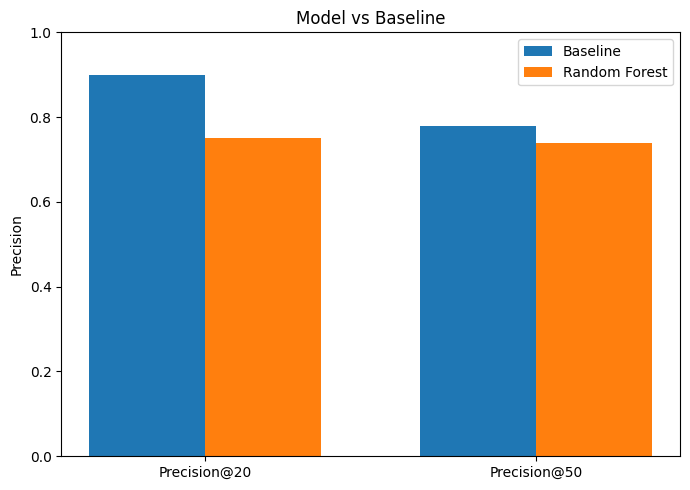


Chart saved to work/outputs/charts/precision_comparison.png


In [36]:
import os
import json
import matplotlib.pyplot as plt

# Create output folders
os.makedirs("work/outputs/charts", exist_ok=True)

# -----------------------------
# Final metrics
# -----------------------------

metrics = {
    "test_rows": int(len(test_model)),
    "base_rate": float(test_model["future_opportunity"].mean()),
    "precision_at_20_baseline": float(
        precision_at_k(test_model, "baseline_score", 20)
    ),
    "precision_at_20_model": float(
        precision_at_k(test_model, "model_score", 20)
    ),
    "precision_at_50_baseline": float(
        precision_at_k(test_model, "baseline_score", 50)
    ),
    "precision_at_50_model": float(
        precision_at_k(test_model, "model_score", 50)
    )
}

with open(
    "work/outputs/capstone_metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved:")
print(metrics)

# -----------------------------
# Precision comparison chart
# -----------------------------

labels = ["Precision@20", "Precision@50"]

baseline_values = [
    metrics["precision_at_20_baseline"],
    metrics["precision_at_50_baseline"]
]

model_values = [
    metrics["precision_at_20_model"],
    metrics["precision_at_50_model"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, model_values, width, label="Random Forest")

plt.xticks(x, labels)
plt.ylabel("Precision")
plt.title("Model vs Baseline")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    "work/outputs/charts/precision_comparison.png",
    dpi=150
)

plt.show()

print(
    "\nChart saved to "
    "work/outputs/charts/precision_comparison.png"
)

In [37]:
import sys
import pandas as pd
import sklearn
import duckdb

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("duckdb:", duckdb.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas: 2.2.3
scikit-learn: 1.6.1
duckdb: 1.3.2


## 5-Minute Demo Outline

**0:00–0:45 — Problem**

Explain the goal: rank content pages that are worth reviewing or refreshing so editors can prioritize their time.

**0:45–1:30 — Data**

Explain the February 2026 feature window, March 2026 future outcome, and the five model features.

**1:30–2:15 — Baseline**

Show the simple baseline using:
- content age
- weak CTR relative to search position

**2:15–3:30 — Model**

Explain the Random Forest and the time-aware training setup.

**3:30–4:30 — Results**

Show the model vs baseline chart:
- Precision@20: 75% vs 65%
- Precision@50: 78% vs 66%
- Base rate: 27.04%

**4:30–5:00 — Recommendation**

Show the ranked review queue and explain that the model helps prioritize human review rather than automatically deciding to refresh a page.

## Social Post

I built a content-opportunity ranking system for the FlyRank ML Internship using pseudonymized search and content data.

A Random Forest ranked pages for future review opportunities and achieved 75% Precision@20 and 78% Precision@50, compared with 65% and 66% for a simple baseline on the same held-out test set.

The output is a ranked review queue that helps editors decide which pages to investigate first.

## Employer-Facing Summary

I built a time-aware Random Forest ranking system to prioritize content pages for review or refresh using search performance and content metadata.

Using 50,625 held-out test items, the model achieved 75% Precision@20 and 78% Precision@50, compared with 65% and 66% for a transparent baseline.

The project demonstrates end-to-end ML skills including feature engineering, leakage control, time-aware validation, baseline comparison, error analysis, and decision-oriented ranking.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
